In [1]:
import json
import pandas as pd
import urllib
# https://data.gov.il/dataset/https-www-data-gov-il-dataset-682
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=2de7b543-e13d-4e7e-b4c8-56071bc4d3c8'
fileobj = urllib.request.urlopen(url)

# Read the content of the fileobj
data_bytes = fileobj.read()

# Decode the bytes to a string
data_str = data_bytes.decode('utf-8')

# Parse the JSON string
data_json = json.loads(data_str)

# Extract the records from the 'result' key
records = data_json.get('result', {}).get('records', [])

# Create a DataFrame from the records
df = pd.DataFrame(records)
df['Survey_Date'] = pd.to_datetime(df['Survey_Date'], format='%d/%m/%Y', errors='coerce')
df['Date'] = df['Survey_Date']

df = df.set_index('Survey_Date')
df = df.sort_index()
df.index
df.index.dtype



dtype('<M8[ns]')

In [2]:
df

,_id,Kinneret_Level,Date
Survey_Date,,,
1966-09-01,11138,-210.020,1966-09-01
1966-09-15,11137,-210.130,1966-09-15
1966-10-01,11136,-210.270,1966-10-01
1966-10-15,11135,-210.320,1966-10-15
1966-11-01,11134,-210.390,1966-11-01
...,...,...,...
2026-02-15,5,-213.115,2026-02-15
2026-02-16,4,-213.115,2026-02-16
2026-02-17,3,-213.115,2026-02-17


In [3]:
df = df.drop(columns=["_id"])
df = df.resample("D").interpolate()   # linear interpolation for small gaps
df = df[['Date', 'Kinneret_Level']]

df

,Date,Kinneret_Level
Survey_Date,,
1966-09-01,1966-09-01,-210.020000
1966-09-02,1966-09-02,-210.027857
1966-09-03,1966-09-03,-210.035714
1966-09-04,1966-09-04,-210.043571
1966-09-05,1966-09-05,-210.051429
...,...,...
2026-02-15,2026-02-15,-213.115000
2026-02-16,2026-02-16,-213.115000
2026-02-17,2026-02-17,-213.115000


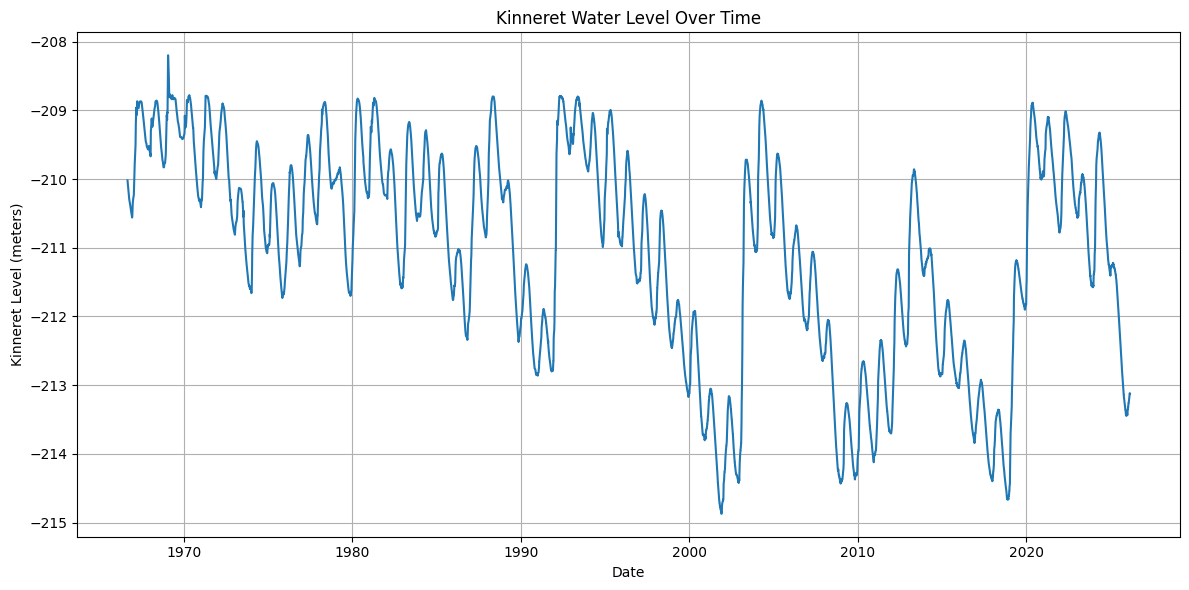

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Kinneret_Level', data=df)
plt.title('Kinneret Water Level Over Time')
plt.xlabel('Date')
plt.ylabel('Kinneret Level (meters)')
plt.grid(True)
plt.tight_layout()
plt.show()

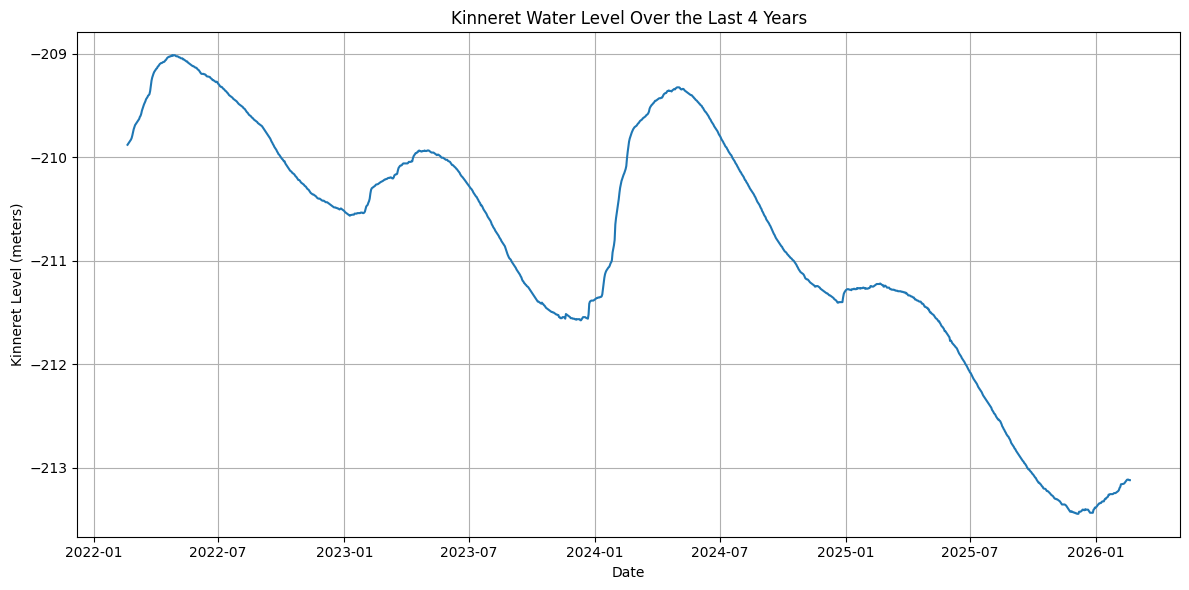

In [5]:
# Get the most recent date in the DataFrame
max_date = df.index.max()

# Calculate the start date for the last year (from the latest date)
start_date_last_year = max_date - pd.DateOffset(years=4)

# Filter the DataFrame for the last year
df_last_year = df[df.index >= start_date_last_year]

# Create the plot for the last year
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Kinneret_Level', data=df_last_year)
plt.title('Kinneret Water Level Over the Last 4 Years')
plt.xlabel('Date')
plt.ylabel('Kinneret Level (meters)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
df.describe()

,Date,Kinneret_Level
count,21722,21722.000000
mean,1996-05-26 12:00:00,-211.038388
min,1966-09-01 00:00:00,-214.870000
25%,1981-07-14 06:00:00,-212.130000
50%,1996-05-26 12:00:00,-210.774643
75%,2011-04-08 18:00:00,-209.780000
max,2026-02-19 00:00:00,-208.200000
std,NaN,1.542517


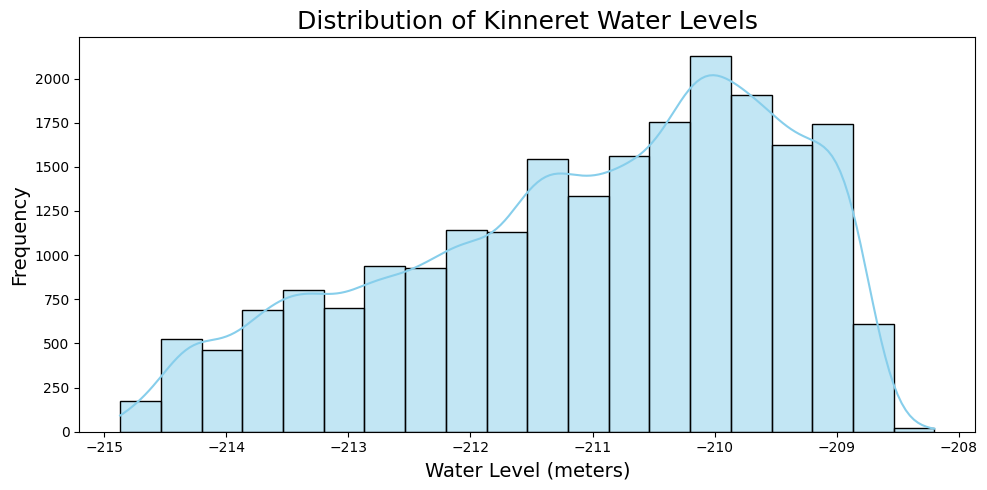

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Kinneret_Level'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Kinneret Water Levels', fontsize=18)
plt.xlabel('Water Level (meters)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
# Quick statistical overview of `df`
import numpy as np
print("Shape:", df.shape)
print("Index range:", df.index.min(), "to", df.index.max())
print("Inferred frequency:", df.index.freq)
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1024**2)
print("\nMissing values:\n", df.isnull().sum())

print("\nKinneret_Level descriptive stats:")
print(df['Kinneret_Level'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# Threshold-based counts
UPPER_RED_LINE = -208.80
LOWER_RED_LINE = -213.00
total = len(df)
below_lower = (df['Kinneret_Level'] <= LOWER_RED_LINE).sum()
between = ((df['Kinneret_Level'] > LOWER_RED_LINE) & (df['Kinneret_Level'] <= UPPER_RED_LINE)).sum()
above_upper = (df['Kinneret_Level'] > UPPER_RED_LINE).sum()
print(f"\nThreshold counts (total {total}):")
print(f" <= LOWER_RED_LINE ({LOWER_RED_LINE}): {below_lower} ({below_lower/total:.2%})")
print(f" between LOWER and UPPER: {between} ({between/total:.2%})")
print(f" > UPPER_RED_LINE ({UPPER_RED_LINE}): {above_upper} ({above_upper/total:.2%})")

# Annual aggregated stats (show last 10 years)
annual = df['Kinneret_Level'].resample('Y').agg(['mean', 'min', 'max', 'std'])
print("\nAnnual stats (tail 10 years):")
print(annual.tail(10))

# Monthly climatology
monthly = df['Kinneret_Level'].groupby(df.index.month).agg(['mean', 'std'])
print("\nMonthly climatology (mean, std):")
print(monthly)

# Autocorrelation (lag 1)
print("\nAutocorrelation (lag=1):", df['Kinneret_Level'].autocorr(lag=1))

# Recent trend (linear fit on last ~10 years)
try:
    recent = df['Kinneret_Level'].last('3650D')
    x = (recent.index.view('int64') / 1e9)  # seconds
    y = recent.values
    slope = np.polyfit(x, y, 1)[0]
    print("\nRecent trend slope (meters/sec):", slope)
    print("Recent trend slope (meters/year):", slope * 3600 * 24 * 365)
except Exception:
    pass

Shape: (21722, 2)
Index range: 1966-09-01 00:00:00 to 2026-02-19 00:00:00
Inferred frequency: <Day>
Memory usage (MB): 0.4971771240234375

Missing values:
 Date              0
Kinneret_Level    0
dtype: int64

Kinneret_Level descriptive stats:
count    21722.000000
mean      -211.038388
std          1.542517
min       -214.870000
1%        -214.435000
5%        -213.925000
25%       -212.130000
50%       -210.774643
75%       -209.780000
95%       -208.935762
99%       -208.810000
max       -208.200000
Name: Kinneret_Level, dtype: float64

Threshold counts (total 21722):
 <= LOWER_RED_LINE (-213.0): 3118 (14.35%)
 between LOWER and UPPER: 18485 (85.10%)
 > UPPER_RED_LINE (-208.8): 119 (0.55%)

Annual stats (tail 10 years):
                   mean      min      max       std
Survey_Date                                        
2017-12-31  -213.594055 -214.395 -212.920  0.499639
2018-12-31  -213.982348 -214.660 -213.355  0.460725
2019-12-31  -211.957664 -214.460 -211.185  0.834567
2020-12

C:\Users\shay\AppData\Local\Temp\ipykernel_20660\3482757363.py:25: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = df['Kinneret_Level'].resample('Y').agg(['mean', 'min', 'max', 'std'])
C:\Users\shay\AppData\Local\Temp\ipykernel_20660\3482757363.py:39: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df['Kinneret_Level'].last('3650D')


In [9]:
# Count outliers using the IQR method and remove them (keep a removed copy + an interpolated clean copy)
q1, q3 = df['Kinneret_Level'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.1375 * iqr
upper_bound = q3 + 1.1375 * iqr

outlier_mask = (df['Kinneret_Level'] < lower_bound) | (df['Kinneret_Level'] > upper_bound)
n_outliers = outlier_mask.sum()
n_total = len(df)

print(f"Outliers: {n_outliers} / {n_total} ({n_outliers/n_total:.2%})")
print(f"Below lower_bound ({lower_bound:.3f}): {(df['Kinneret_Level'] < lower_bound).sum()}")
print(f"Above upper_bound ({upper_bound:.3f}): {(df['Kinneret_Level'] > upper_bound).sum()}")

# 1) DataFrame with outlier rows removed
df_no_outliers = df[~outlier_mask].copy()
print(f"\ndf_no_outliers shape: {df_no_outliers.shape}")

# 2) Alternative: replace outliers with NaN and interpolate to preserve daily index continuity
df_clean = df.copy()
df_clean.loc[outlier_mask, 'Kinneret_Level'] = np.nan
df_clean['Kinneret_Level'] = df_clean['Kinneret_Level'].interpolate(method='time')
print(f"df_clean shape (after interpolation): {df_clean.shape}")

Outliers: 27 / 21722 (0.12%)
Below lower_bound (-214.803): 27
Above upper_bound (-207.107): 0

df_no_outliers shape: (21695, 2)
df_clean shape (after interpolation): (21722, 2)


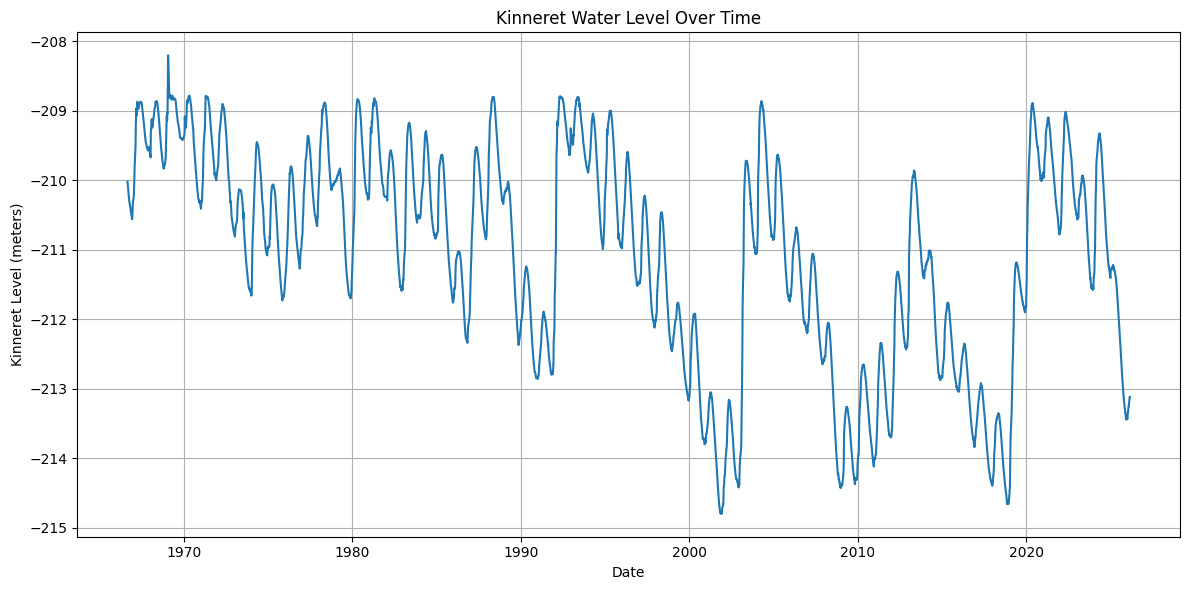

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Kinneret_Level', data=df_clean)
plt.title('Kinneret Water Level Over Time')
plt.xlabel('Date')
plt.ylabel('Kinneret Level (meters)')
plt.grid(True)
plt.tight_layout()
plt.show()

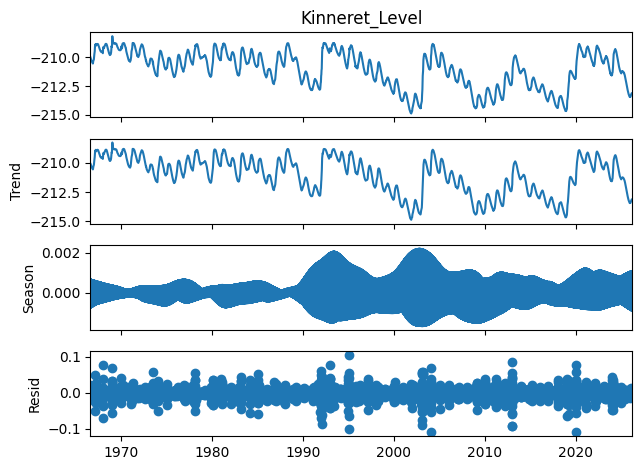

In [11]:
from statsmodels.tsa.seasonal import STL

stl = STL(df['Kinneret_Level'], seasonal=365)
res = stl.fit()
fig = res.plot()

In [12]:
# ADF test
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
    """Using an ADF test to determine if a series is stationary"""
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))
adf_test(df["Kinneret_Level"][1:])

ADF Statistic:  -6.257102757415478
P-Value:  4.3121626943033756e-08
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57


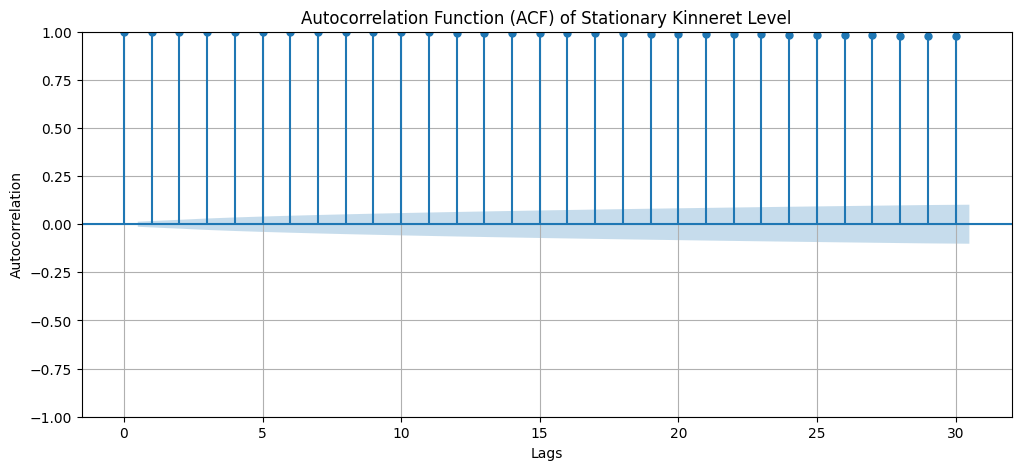

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plot_acf(df['Kinneret_Level'], lags=30, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Stationary Kinneret Level')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

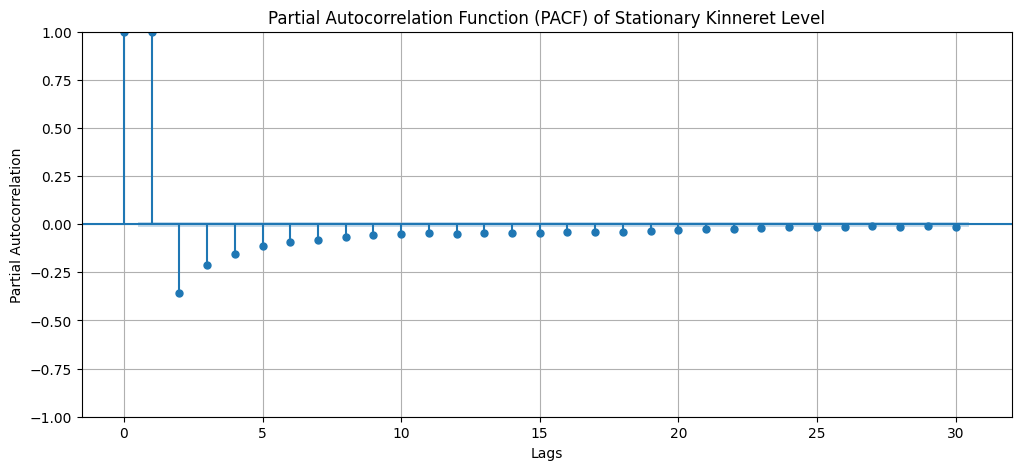

In [14]:
plt.figure(figsize=(12, 5))
plot_pacf(df['Kinneret_Level'], lags=30, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Stationary Kinneret Level')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [15]:
# Calculate the cutoff date for the test set (last 1 year)
cutoff_date = df.index.max() - pd.DateOffset(years=1)

# Split the data into training and testing sets
train_df = df[df.index < cutoff_date]
test_df = df[df.index >= cutoff_date]

print(f"Shape of training data: {train_df.shape}")
print(f"Shape of testing data: {test_df.shape}")

Shape of training data: (21356, 2)
Shape of testing data: (366, 2)


In [16]:
train_df.head()


,Date,Kinneret_Level
Survey_Date,,
1966-09-01,1966-09-01,-210.020000
1966-09-02,1966-09-02,-210.027857
1966-09-03,1966-09-03,-210.035714
1966-09-04,1966-09-04,-210.043571
1966-09-05,1966-09-05,-210.051429


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def evaluate_model(model, X_test, y_test, model_name="Model"):

    predictions = model.predict(X_test)

    # 2. Calculate Metrics
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # 3. Professional Printout
    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2%}") # Displayed as a percentage
    print(f"R² Score: {r2:.4f}")
    print("-" * (24 + len(model_name)))

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(model, X_test, actuals, model_name="Model"):
    """
    Runs inference and generates a professional two-panel diagnostic:
    1. Actual vs Predicted overlay
    2. Residual error plot to check for missed patterns
    """
    # 1. Run the evaluation (Inference)
    # Note: Ensure X_test is preprocessed the same way the model was trained
    preds_raw = model.predict(X_test)

    # Convert predictions to a Series with the same index as actuals for correct alignment
    predictions = pd.Series(preds_raw, index=actuals.index)
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=actuals.index, y=actuals.values, label='Actual Kinneret Level', color='blue')
    sns.lineplot(x=predictions.index, y=predictions.values, label=f'{model_name} Predictions', color='red', linestyle='--')
    plt.title(f'{model_name}: Actual vs. Predicted Kinneret Levels')
    plt.xlabel('Date')
    plt.ylabel('Kinneret Level (meters)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [19]:
# Split training data into features (X_train) and target (y_train)
X_train = train_df['Date']
y_train = train_df['Kinneret_Level']

# Split testing data into features (X_test) and target (y_test)
X_test = test_df['Date']
y_test = test_df['Kinneret_Level']

print(f"Shape of train: {train_df.shape}")
print(f"Shape of test: {test_df.shape}")

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of train: (21356, 2)
Shape of test: (366, 2)
Shape of X_train: (21356,)
Shape of y_train: (21356,)
Shape of X_test: (366,)
Shape of y_test: (366,)


In [20]:
print("X_train:")
print(X_train.head())
print("\ny_train:")
print(y_train.head())

X_train:
Survey_Date
1966-09-01   1966-09-01
1966-09-02   1966-09-02
1966-09-03   1966-09-03
1966-09-04   1966-09-04
1966-09-05   1966-09-05
Freq: D, Name: Date, dtype: datetime64[ns]

y_train:
Survey_Date
1966-09-01   -210.020000
1966-09-02   -210.027857
1966-09-03   -210.035714
1966-09-04   -210.043571
1966-09-05   -210.051429
Freq: D, Name: Kinneret_Level, dtype: float64


#stationarity

In [21]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(y_train, order=(1, 0, 1))
arima_model_fit = model.fit()
print("ARIMA model fitted successfully.")

ARIMA model fitted successfully.


In [22]:
def evaluate_arima(model_fit, y_test, model_name="ARIMA"):

    n_test = len(y_test)

    predictions = model_fit.forecast(steps=n_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2%}")
    print(f"R² Score: {r2:.4f}")
    print("-" * (24 + len(model_name)))

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}


In [23]:
stats_arima = evaluate_arima(
    model_fit=arima_model_fit,
    y_test=y_test,
    model_name="ARIMA"
)


--- ARIMA Performance ---
MAE:  1.2520
RMSE: 1.4873
MAPE: 0.59%
R² Score: -2.4433
-----------------------------


In [24]:
def plot_arima_forecast(
    model_fit,
    y_test,
    title="ARIMA Forecast (Test Only)",
    show_ci=True
):

    n_test = len(y_test)

    # Forecast
    forecast_res = model_fit.get_forecast(steps=n_test)
    forecast = forecast_res.predicted_mean

    # Confidence intervals
    if show_ci:
        conf_int = forecast_res.conf_int()

    # Align index with test set
    forecast.index = y_test.index
    if show_ci:
        conf_int.index = y_test.index

    # Plot only test vs forecast
    plt.figure(figsize=(12, 5))
    plt.plot(y_test, label="Actual (Test)", color="black")
    plt.plot(forecast, label="Forecast", linestyle="--")

    if show_ci:
        plt.fill_between(
            conf_int.index,
            conf_int.iloc[:, 0],
            conf_int.iloc[:, 1],
            alpha=0.2,
            label="Confidence Interval"
        )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


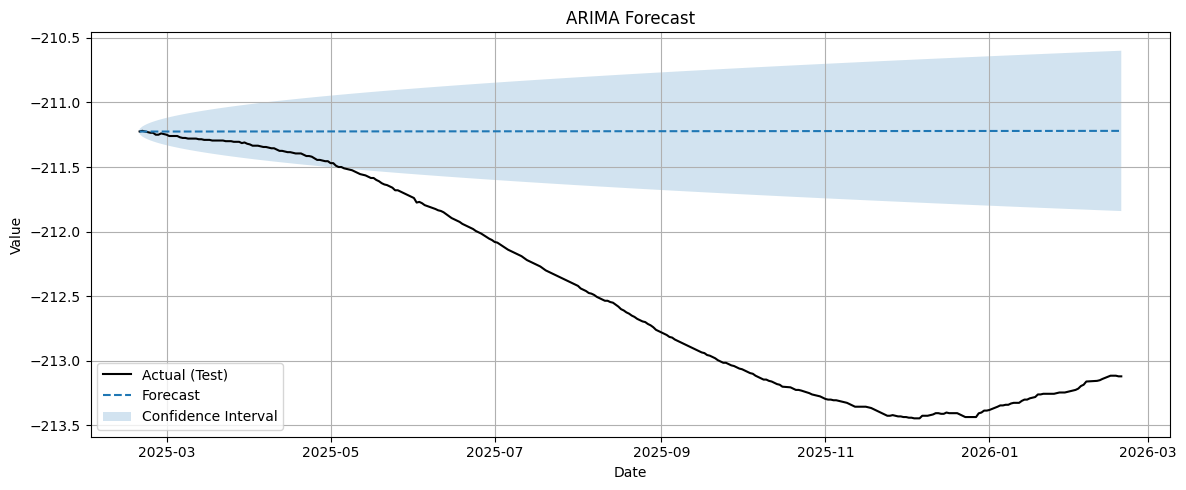

In [25]:
plot_arima_forecast(
    model_fit=arima_model_fit,
    y_test=y_test,
    title="ARIMA Forecast"
)


#Exponential Smoothing

c:\Users\shay\anaconda3\envs\yolov8-gpu\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Exponential Smoothing model fitted successfully.
--- Exponential Smoothing Performance ---
MAE:  2.9715
RMSE: 3.4585
MAPE: 1.40%
R² Score: -17.6184
---------------------------------------------


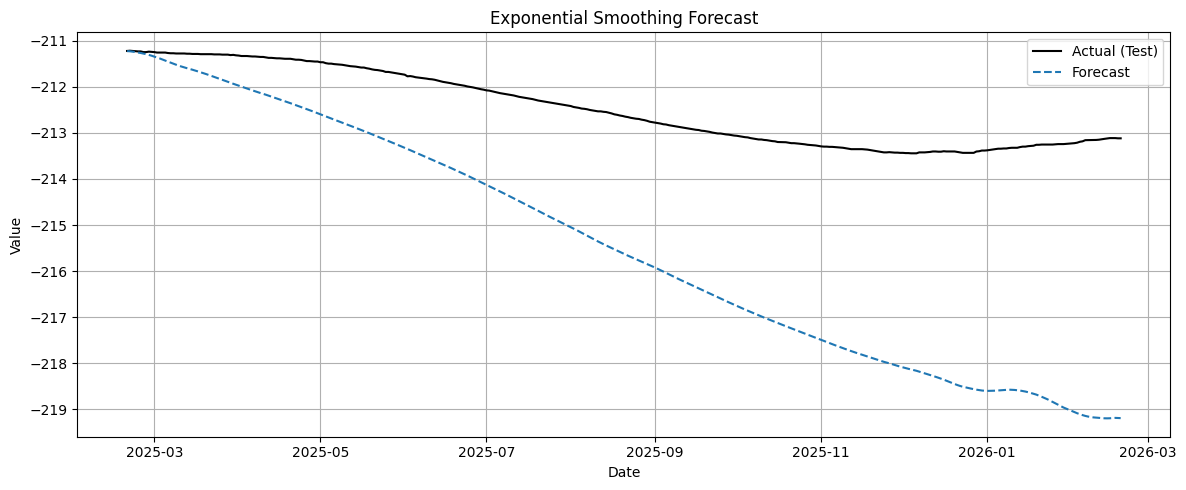

In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def train_ets(y_train, seasonal_periods=365, trend='add', seasonal='add'):
    """
    Trains an Exponential Smoothing model.
    """
    # Use seasonal_periods=365 for daily data with yearly seasonality
    model = ExponentialSmoothing(
        y_train,
        seasonal_periods=seasonal_periods,
        trend=trend,
        seasonal=seasonal,
        initialization_method="estimated"
    )
    ets_model_fit = model.fit()
    print("Exponential Smoothing model fitted successfully.")
    return ets_model_fit

def evaluate_ets(model_fit, y_test, model_name="ETS"):
    """
    Evaluates the ETS model predictions against actual values.
    """
    n_test = len(y_test)
    predictions = model_fit.forecast(steps=n_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2%}")
    print(f"R² Score: {r2:.4f}")
    print("-" * (24 + len(model_name)))

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

def plot_ets_forecast(model_fit, y_test, title="ETS Forecast (Test Only)"):
    """
    Plots only the test period: actual vs forecast.
    """
    n_test = len(y_test)

    # Generate forecast
    forecast = model_fit.forecast(steps=n_test)

    # Align index with test set
    forecast.index = y_test.index

    # Plot only test vs forecast
    plt.figure(figsize=(12, 5))
    plt.plot(y_test, label="Actual (Test)", color="black")
    plt.plot(forecast, label="Forecast", linestyle="--")

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Train the ETS model
ets_model_fit = train_ets(y_train, seasonal_periods=365, trend='add', seasonal='add')

# Evaluate the ETS model
stats_ets = evaluate_ets(
    model_fit=ets_model_fit,
    y_test=y_test,
    model_name="Exponential Smoothing"
)

# Plot the forecast
plot_ets_forecast(
    model_fit=ets_model_fit,
    y_test=y_test,
    title="Exponential Smoothing Forecast"
)


#Prophet

In [27]:
from prophet import Prophet

def prepare_prophet_data(df, date_col, target_col):
    prophet_df = df[[date_col, target_col]].rename(
        columns={date_col: "ds", target_col: "y"}
    )
    return prophet_df

c:\Users\shay\anaconda3\envs\yolov8-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [28]:
def train_prophet(train_df):
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.fit(train_df)
    return model


In [29]:
def evaluate_prophet(model, test_df, model_name="Prophet"):
    """
    test_df must contain columns ['ds', 'y']
    """

    forecast = model.predict(test_df[['ds']])

    y_true = test_df['y']
    y_pred = forecast['yhat']

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2%}")
    print(f"R² Score: {r2:.4f}")
    print("-" * (24 + len(model_name)))

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [30]:
def plot_prophet_forecast(
    model,
    train_df,
    test_df,
    title="Prophet Forecast"
):
    forecast = model.predict(test_df[['ds']])

    plt.figure(figsize=(12, 5))

    plt.plot(train_df['ds'], train_df['y'], label="Train")
    plt.plot(test_df['ds'], test_df['y'], label="Test", color="black")

    plt.plot(
        forecast['ds'],
        forecast['yhat'],
        label="Forecast",
        linestyle="--"
    )

    plt.fill_between(
        forecast['ds'],
        forecast['yhat_lower'],
        forecast['yhat_upper'],
        alpha=0.2,
        label="Confidence Interval"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
df.columns

Index(['Date', 'Kinneret_Level'], dtype='object')

16:28:46 - cmdstanpy - INFO - Chain [1] start processing
16:29:09 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Performance ---
MAE:  2.3845
RMSE: 2.4232
MAPE: 1.12%
R² Score: -8.1761
-------------------------------


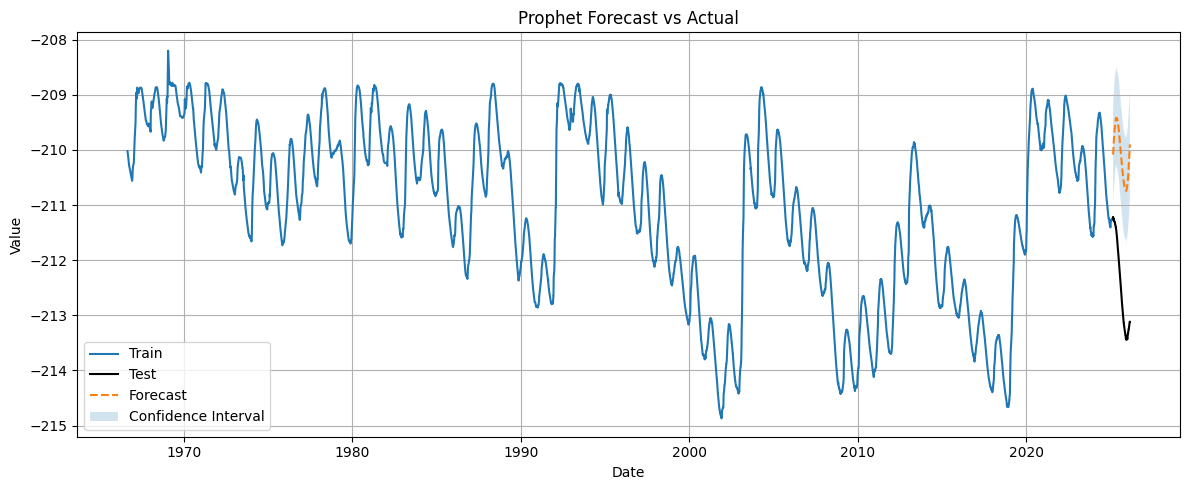

In [32]:
# Prepare data
prophet_df = prepare_prophet_data(df, date_col="Date", target_col="Kinneret_Level")

# Time-based split
train_df = prophet_df.iloc[:-365]
test_df = prophet_df.iloc[-365:]

# Train
prophet_model = train_prophet(train_df)

# Evaluate
stats_prophet = evaluate_prophet(
    model=prophet_model,
    test_df=test_df,
    model_name="Prophet"
)

# Plot
plot_prophet_forecast(
    model=prophet_model,
    train_df=train_df,
    test_df=test_df,
    title="Prophet Forecast vs Actual"
)


#Feature Engineering



In [33]:
df

,Date,Kinneret_Level
Survey_Date,,
1966-09-01,1966-09-01,-210.020000
1966-09-02,1966-09-02,-210.027857
1966-09-03,1966-09-03,-210.035714
1966-09-04,1966-09-04,-210.043571
1966-09-05,1966-09-05,-210.051429
...,...,...
2026-02-15,2026-02-15,-213.115000
2026-02-16,2026-02-16,-213.115000
2026-02-17,2026-02-17,-213.115000


In [34]:
Do_Lags = True

if Do_Lags:
    lags_Use = [ 7, 30, 365]#////     lags_Use = [1, 2, 3, 7, 30, 365]
else:
    lags_Use = None

Do_windows = True

if Do_windows:
    windows_Use = [7, 30, 90]#////     windows_Use = [7, 30, 90]
else:
    windows_Use = None

def engineer_kinneret_features(df, lags = lags_Use, windows = windows_Use):
    """
    Performs extensive feature engineering on Kinneret water level data.
    """
    # 1. PREPROCESSING
    # ---------------------------------------------------------
    # Ensure Date is datetime and set as index for easier time-based manipulation
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date').sort_index()
    elif 'Survey_Date' in df.columns: # Handling the column name from your image
        df['Date'] = pd.to_datetime(df['Survey_Date'])
        df = df.set_index('Date').sort_index()

    # Drop duplicates just in case
    df = df[~df.index.duplicated(keep='first')]

    # 2. TEMPORAL FEATURES (Calendar)
    # ---------------------------------------------------------
    df['Day_of_Week'] = df.index.dayofweek
    df['DayOfWeek_Sin'] = np.sin(2 * np.pi * df['Day_of_Week'] / 7)
    df['DayOfWeek_Cos'] = np.cos(2 * np.pi * df['Day_of_Week'] / 7)
    df['Day_of_Month'] = df.index.day
    df['DayOfMonth_Sin'] = np.sin(2 * np.pi * df['Day_of_Month'] / 31)
    df['DayOfMonth_Cos'] = np.cos(2 * np.pi * df['Day_of_Month'] / 31)
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    df['Day_of_Year'] = df.index.dayofyear

    # 3. CYCLICAL ENCODING (Sin/Cos)
    # ---------------------------------------------------------
    # This helps the model understand that Dec (12) is next to Jan (1)

    # Month (12 cycle)
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

    # Day of Year (365 cycle)
    df['DayYear_Sin'] = np.sin(2 * np.pi * df['Day_of_Year'] / 365.25)
    df['DayYear_Cos'] = np.cos(2 * np.pi * df['Day_of_Year'] / 365.25)

    # 4. LAG FEATURES (Autoregression)
    # ---------------------------------------------------------
    # Note: These introduce NaNs at the start of the data
    if lags is not None:
        for lag in lags:
            df[f'Lag_{lag}'] = df['Kinneret_Level'].shift(lag)

    # 5. ROLLING WINDOW STATISTICS
    # ---------------------------------------------------------
    # Captures trends and volatility over different time horizons
    if windows is not None:
        for w in windows:
            # Rolling Mean (Trend)
            df[f'Roll_Mean_{w}d'] = df['Kinneret_Level'].shift(1).rolling(window=w).mean()
            # Rolling Std (Volatility)
            df[f'Roll_Std_{w}d'] = df['Kinneret_Level'].shift(1).rolling(window=w).std()
            # Rolling Min/Max (Range)
            df[f'Roll_Max_{w}d'] = df['Kinneret_Level'].shift(1).rolling(window=w).max()
            df[f'Roll_Min_{w}d'] = df['Kinneret_Level'].shift(1).rolling(window=w).min()


    # 7. DOMAIN SPECIFIC (Kinneret Thresholds)
    # ---------------------------------------------------------
    # Based on standard Sea of Galilee benchmarks (in meters)
    UPPER_RED_LINE = -208.80
    LOWER_RED_LINE = -213.00
    #BLACK_LINE = -214.87

    # Binary Flags (Booleans converted to int for models)
    if lags is not None and 1 in lags:
        df['distance_Upper_Red'] = df['Kinneret_Level'].shift(1) - UPPER_RED_LINE
        df['distance_Lower_Red'] = LOWER_RED_LINE - df['Kinneret_Level'].shift(1)

    #df['Below_Black_Line'] = (df['Kinneret_Level'].shift(1) <= BLACK_LINE).astype(int)

    # Season Flag (Simplistic: Winter=Rain vs Summer=Evaporation)
    df['Is_Rain_Season'] = df['Month'].isin([11, 12, 1, 2, 3]).astype(int)
    Delta_1 = False
    if lags is not None and 1 in lags and 2 in lags and len(df) >= 2 and Delta_1 is True:
        df['Delta_1'] = df['Kinneret_Level'].shift(1) - df['Kinneret_Level'].shift(2)
    # 8. CLEANUP
    # ---------------------------------------------------------
    # Drop rows with NaN values created by shifting/rolling (optional but recommended for training)
    # The largest lag/window is 365, so we lose the first year of data
    df_clean = df.dropna()

    return df_clean



In [35]:
cutoff_date = df.index.max() - pd.DateOffset(years=1)

train = df[df.index < cutoff_date]

test = df[df.index >= cutoff_date]

print(f"Training Range: {X_train.index.min()} to {X_train.index.max()}")
print(f"Testing Range:  {X_test.index.min()} to {X_test.index.max()}")


train = engineer_kinneret_features(train)

print(train.head())
print(f"Total Features: {train.shape[1]}")
print(f"the shape of the dataset:{train.shape}")

Training Range: 1966-09-01 00:00:00 to 2025-02-18 00:00:00
Testing Range:  2025-02-19 00:00:00 to 2026-02-19 00:00:00
            Kinneret_Level  Day_of_Week  DayOfWeek_Sin  DayOfWeek_Cos  \
Date                                                                    
1967-09-01     -209.273333            4      -0.433884      -0.900969   
1967-09-02     -209.280000            5      -0.974928      -0.222521   
1967-09-03     -209.285000            6      -0.781831       0.623490   
1967-09-04     -209.290000            0       0.000000       1.000000   
1967-09-05     -209.295000            1       0.781831       0.623490   

            Day_of_Month  DayOfMonth_Sin  DayOfMonth_Cos  Month  Year  \
Date                                                                    
1967-09-01             1        0.201299        0.979530      9  1967   
1967-09-02             2        0.394356        0.918958      9  1967   
1967-09-03             3        0.571268        0.820763      9  1967   
1967-

C:\Users\shay\AppData\Local\Temp\ipykernel_20660\1099107019.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


In [36]:
def recursive_forecast(model, history_series, periods, start_index=None, freq=None, lags = lags_Use, windows = windows_Use):
    """
    model: trained one-step regressor that accepts a DataFrame with same feature columns as training X
    history_series: pd.Series of true Kinneret_Level up to and including the last known timestamp
    periods: number of steps to predict
    start_index: timestamp for the first forecasted step (datetime)
    freq: optional Pandas offset or Timedelta; if None we infer from history_series.index
    Returns: np.array of length `periods` (predictions) and a DatetimeIndex for them
    """

    history = history_series.copy()
    if not isinstance(history.index, pd.DatetimeIndex):
        raise ValueError("history_series must have a DatetimeIndex")

    # infer freq / step
    if freq is None:
        freq = history.index.freq
        if freq is None:
            # fallback: use difference of last two indices
            if len(history.index) < 2:
                raise ValueError("Cannot infer frequency from history with <2 timestamps; pass freq explicitly")
            freq = history.index[-1] - history.index[-2]

    if start_index is None:
        start_index = history.index[-1] + pd.Timedelta(freq)

    preds = []
    pred_index = []

    current_time = pd.to_datetime(start_index)

    for i in range(periods):
        # Build feature row from `history` (only past info)
        feat = {}

        # Datetime parts
        feat['Day_of_Week'] = current_time.dayofweek
        feat['DayOfWeek_Sin'] = np.sin(2*np.pi*feat['Day_of_Week']/7)
        feat['DayOfWeek_Cos'] = np.cos(2*np.pi*feat['Day_of_Week']/7)
        feat['Day_of_Month'] = current_time.day
        feat['DayOfMonth_Sin'] = np.sin(2*np.pi*feat['Day_of_Month']/31)
        feat['DayOfMonth_Cos'] = np.cos(2*np.pi*feat['Day_of_Month']/31)
        feat['Month'] = current_time.month
        feat['Year'] = current_time.year
        feat['Day_of_Year'] = current_time.timetuple().tm_yday
        feat['Month_Sin'] = np.sin(2*np.pi*feat['Month']/12)
        feat['Month_Cos'] = np.cos(2*np.pi*feat['Month']/12)
        feat['DayYear_Sin'] = np.sin(2*np.pi*feat['Day_of_Year']/365.25)
        feat['DayYear_Cos'] = np.cos(2*np.pi*feat['Day_of_Year']/365.25)

        # Lag features: require enough history
        if lags is not None:
            for lag in lags:
                if len(history) < lag:
                    raise ValueError(f"Not enough history to compute lag_{lag} (need {lag} rows)", len(history))
                feat[f'Lag_{lag}'] = history.iloc[-lag]

        # Rolling features: compute from last w values (shifted by design: we use history excluding current time)
        if windows is not None:
            for w in windows:
                if len(history) < w:
                    # choose behavior: compute with available history (could be NaN) or raise. We'll compute with available values.
                    val_mean = history.iloc[-len(history):].mean()
                    val_std = history.iloc[-len(history):].std()
                    val_max = history.iloc[-len(history):].max()
                    val_min = history.iloc[-len(history):].min()
                else:
                    val_mean = history.iloc[-w:].mean()
                    val_std = history.iloc[-w:].std()
                    val_max = history.iloc[-w:].max()
                    val_min = history.iloc[-w:].min()
                    val_mean = history.iloc[-w:].mean()
                    val_std = history.iloc[-w:].std()
                    val_max = history.iloc[-w:].max()
                    val_min = history.iloc[-w:].min()

                feat[f'Roll_Mean_{w}d'] = val_mean
                feat[f'Roll_Std_{w}d'] = val_std
                feat[f'Roll_Max_{w}d'] = val_max
                feat[f'Roll_Min_{w}d'] = val_min
        # Domain flags based on last known value
        UPPER_RED_LINE = -208.80
        LOWER_RED_LINE = -213.00
        last_val = history.iloc[-1]
        if lags is not None and 1 in lags:
            feat['distance_Upper_Red'] = last_val - UPPER_RED_LINE
            feat['distance_Lower_Red'] = LOWER_RED_LINE - last_val
        feat['Is_Rain_Season'] = int(current_time.month in [11,12,1,2,3])
        Delta_1 = False
        if lags is not None and 1 and 2 in lags and len(history) >= 2 and Delta_1 is True and history.iloc[-1] is not None and history.iloc[-2] is not None:
            feat['Delta_1'] = history.iloc[-1] - history.iloc[-2]

        X_row = pd.DataFrame([feat])

        # Model predict
        yhat = model.predict(X_row)[0]
        preds.append(yhat)
        pred_index.append(current_time)

        new_series = pd.Series([yhat], index=[current_time])
        history = pd.concat([history, new_series])

        # advance time
        current_time = current_time + pd.Timedelta(freq)

    return pd.Series(preds, index=pd.DatetimeIndex(pred_index))


#training

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from math import sqrt

RNG = 42

def train_and_evaluate_recursive_with_test(
    test=test,
    target_col='Kinneret_Level',
    train=train,
    model=None,
    dropna=True,
    verbose=True
):
    """
    Train on data before cutoff_date = max_index - years_test, then recursively forecast the test period
    using only history (no precomputed test features). Assumes make_train_features(...) and
    recursive_forecast(...) are defined and available in the environment.

    Returns: dict with model, X_train, y_train, preds (Series), y_test (Series), metrics, train_df, test_df
    """

    if model is None:
        model = RandomForestRegressor(n_estimators=500, random_state=RNG)


    # 2) train spilt
    X_train, y_train = train.drop(columns=[target_col]), train[target_col]


    # 3) Fit model on X_train / y_train
    model.fit(X_train, y_train)

    # 4) Prepare history up to last known timestamp (true values only)
    last_known_time = train.index.max()
    history_series = df[target_col].loc[:last_known_time].copy()


    # 5) Recursive forecast for the entire test period
    start_index = test.index[0]
    preds = recursive_forecast(
        model=model,
        history_series=history_series,
        periods=len(test),
        start_index=start_index
    )

    # 6) Align and evaluate using true test values
    # Make sure we compare only the forecasted length (preds) to test values
    y_test = test[target_col].iloc[:len(preds)].copy()

    mae = mean_absolute_error(y_test.values, preds.values)
    rmse = sqrt(mean_squared_error(y_test.values, preds.values))
    mape = mean_absolute_percentage_error(y_test.values, preds.values)

    metrics = {'mae': mae, 'rmse': rmse, 'mape': mape}


    if verbose:
        print("Evaluation on test period (recursive):")
        print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.4f}")


    return {
        'model': model,
        'X_train': X_train,
        'y_train': y_train,
        'preds': preds,
        'y_test': y_test,
        'metrics': metrics,
        'train_df': train,
        'test_df': test,
        'cutoff_date': cutoff_date
    }


In [38]:
# df must have DatetimeIndex and 'Kinneret_Level' column
result = train_and_evaluate_recursive_with_test(test=test,train=train)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])
result['preds']
test['Kinneret_Level'].iloc[:len(preds)]


Evaluation on test period (recursive):
MAE: 0.8962 | RMSE: 1.0445 | MAPE: 0.0042
{'mae': 0.8962023143694116, 'rmse': 1.0444597972194472, 'mape': 0.0042084834470536335}


Survey_Date
2025-02-19   -211.225
2025-02-20   -211.220
2025-02-21   -211.225
2025-02-22   -211.230
2025-02-23   -211.235
               ...   
2026-02-15   -213.115
2026-02-16   -213.115
2026-02-17   -213.115
2026-02-18   -213.120
2026-02-19   -213.120
Freq: D, Name: Kinneret_Level, Length: 366, dtype: float64

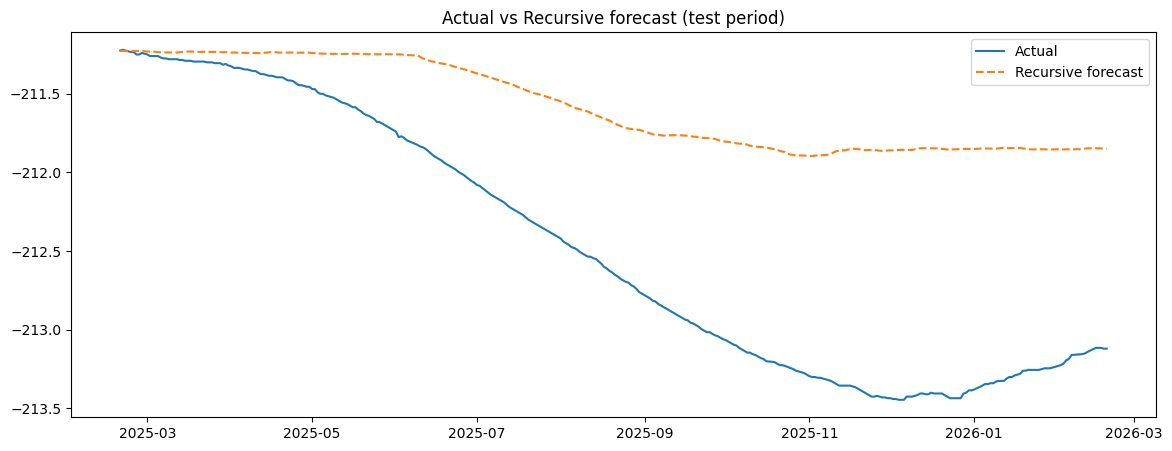

In [39]:
#RandomForestRegressor(n_estimators=500, random_state=RNG)
plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()

In [40]:
import warnings
warnings.filterwarnings('ignore')

Evaluation on test period (recursive):
MAE: 0.4464 | RMSE: 0.4893 | MAPE: 0.0021
{'mae': 0.4463576726861334, 'rmse': 0.48925746204385373, 'mape': 0.0020976466379337678}


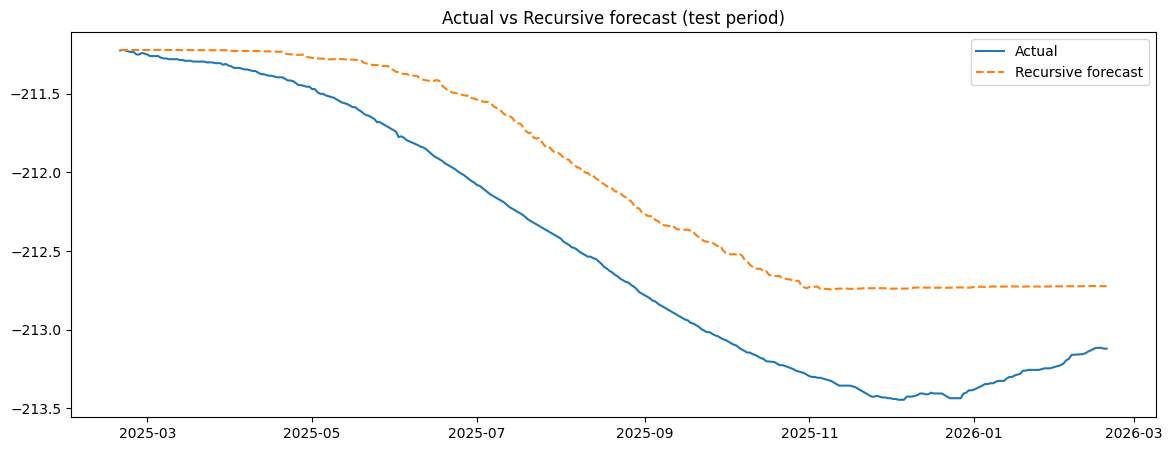

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)
result = train_and_evaluate_recursive_with_test(test=test,train=train,model=xgb)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])

plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()
#best params rn

In [42]:
importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))


Roll_Max_7d       0.582871
Roll_Mean_7d      0.318812
Roll_Min_7d       0.097160
Lag_7             0.000492
Is_Rain_Season    0.000244
Month_Sin         0.000081
Day_of_Year       0.000070
Month             0.000062
DayYear_Cos       0.000033
Roll_Std_7d       0.000032
Lag_30            0.000031
DayYear_Sin       0.000022
Roll_Mean_90d     0.000020
Roll_Min_90d      0.000011
Roll_Max_90d      0.000010
Roll_Std_30d      0.000008
Roll_Min_30d      0.000007
Month_Cos         0.000007
Roll_Max_30d      0.000006
Year              0.000005
dtype: float32


[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4787
[LightGBM] [Info] Number of data points in the train set: 20991, number of used features: 29
[LightGBM] [Info] Start training from score -211.038734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

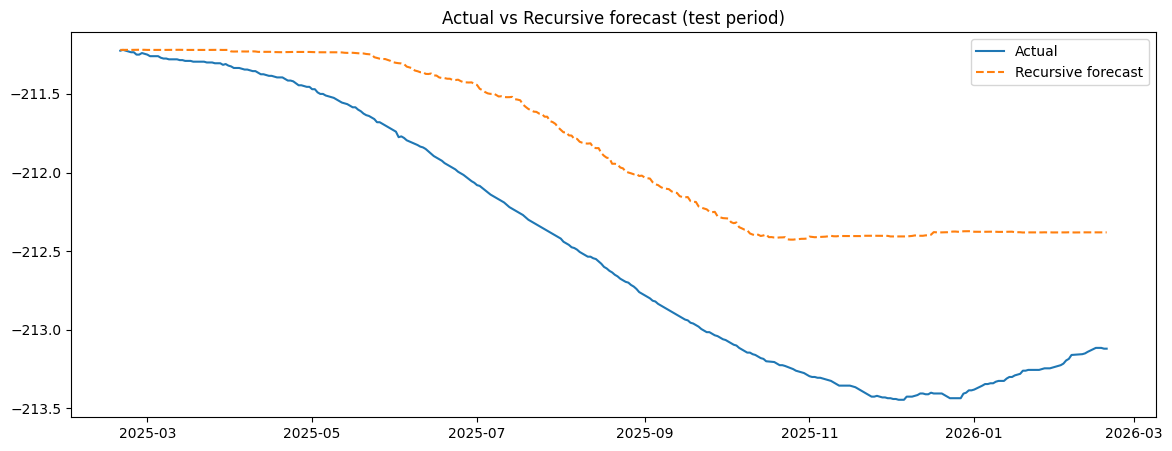

Roll_Max_7d      3157
Roll_Std_7d      2943
Day_of_Year      1844
Lag_365          1497
DayYear_Cos      1385
Roll_Std_90d     1249
Year             1247
Roll_Std_30d     1193
DayYear_Sin      1025
Roll_Mean_7d      966
Roll_Max_90d      780
Roll_Min_90d      772
Roll_Min_7d       721
Month_Sin         551
Roll_Mean_90d     480
Roll_Max_30d      448
Lag_30            431
Roll_Min_30d      418
Roll_Mean_30d     390
Month_Cos         384
dtype: int32


In [43]:
import lightgbm as lgb
model_LightGBM = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    tree_method="hist",
    random_state=42
)
result = train_and_evaluate_recursive_with_test(test=test,train=train,model=model_LightGBM)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])

plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()

importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))

Evaluation on test period (recursive):
MAE: 0.4909 | RMSE: 0.5399 | MAPE: 0.0023
{'mae': 0.49094234262458486, 'rmse': 0.5398565791839067, 'mape': 0.002306804045721119}


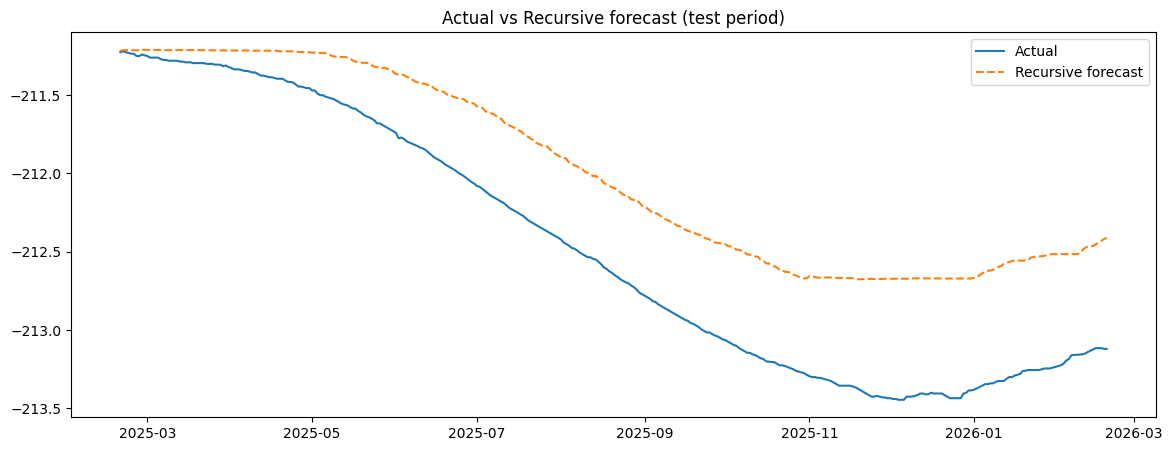

Roll_Max_7d       0.796676
Roll_Mean_7d      0.155996
Roll_Min_7d       0.045434
Lag_7             0.000831
Roll_Max_30d      0.000367
Day_of_Year       0.000130
Roll_Std_7d       0.000099
Lag_30            0.000084
DayYear_Cos       0.000084
Roll_Mean_90d     0.000067
Is_Rain_Season    0.000049
Roll_Mean_30d     0.000033
DayYear_Sin       0.000031
Month_Sin         0.000021
Roll_Max_90d      0.000018
Roll_Std_30d      0.000017
Month             0.000017
Roll_Min_30d      0.000012
Roll_Min_90d      0.000011
Roll_Std_90d      0.000006
dtype: float64


In [44]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    subsample=0.8,
    max_features=0.7,
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=42,
    verbose=0
    )
result = train_and_evaluate_recursive_with_test(test=test,train=train,model=gb)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])

plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()

importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))


In [45]:
!nvidia-smi

Sat Feb 21 16:32:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| 41%   61C    P0             44W /  125W |     889MiB /   6144MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [46]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [47]:
import optuna
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from math import sqrt

# ==========================================
# 1. RECURSIVE OPTUNA OBJECTIVE FUNCTION (LightGBM)
# ==========================================
def objective(trial):
    """
    Optimizes LightGBM hyperparameters using Recursive Time Series Cross-Validation.
    Uses the same recursive_forecast and train/validation splitting as your XGB version.
    """

    # 1. Define Search Space for LightGBM
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 4000),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.001, 3e-1),
        "num_leaves": trial.suggest_int("num_leaves", 8, 512),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 1, 500),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 0, 10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 0.001, 100),

        "random_state": 42,
        "verbose": -1,
        "n_jobs": -1
    }

    # 2. Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=8, test_size=365)
    scores = []

    # 'train' should be your feature-engineered dataframe (same as in your XGB code)
    X = train.drop(columns=['Kinneret_Level'])
    y = train['Kinneret_Level']

    for train_idx, val_idx in tscv.split(X):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        y_val_actual = y.iloc[val_idx]

        # Train the model on the training slice
        model = lgb.LGBMRegressor(**param)
        model.fit(X_tr, y_tr)

        # 3. THE RECURSIVE STEP
        history_series = y.iloc[train_idx]

        preds_series = recursive_forecast(
            model=model,
            history_series=history_series,
            periods=len(val_idx),
            start_index=y_val_actual.index[0]
        )

        # 4. Evaluate using RMSE on the recursive predictions
        rmse = sqrt(mean_squared_error(y_val_actual, preds_series))
        scores.append(rmse)

    # Return the average recursive RMSE across splits
    return np.mean(scores)


# ==========================================
# 2. RUN RECURSIVE TUNING (LightGBM)
# ==========================================
print("Starting Recursive Optuna Hyperparameter Tuning for LightGBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=450, show_progress_bar=True)

print("\nBest Parameters found via Recursive Validation (LightGBM):")
print(study.best_params)


# ==========================================
# 3. TRAIN FINAL MODEL WITH BEST PARAMS (LightGBM)
# ==========================================
lgb_best_params = study.best_params

# Build final LightGBM regressor. Ensure the objective is regression and use all cores.
lgb_recursive_final_model = lgb.LGBMRegressor(**lgb_best_params, objective='regression', n_jobs=-1)

# Run final recursive evaluation on your actual TEST set
result = train_and_evaluate_recursive_with_test(test=test, train=train, model=lgb_recursive_final_model)
print("Final Recursive Test Metrics (LightGBM):", result['metrics'])

#[I 2026-02-18 21:46:28,912] Trial 380 finished with value: 0.32918238770110614 and parameters: {'n_estimators': 2705, 'learning_rate': 0.032779968624430514, 'num_leaves': 98, 'max_depth': 5, 'min_child_samples': 33, 'min_split_gain': 0.0056320689837478545, 'subsample': 0.8820334531346841, 'subsample_freq': 5, 'colsample_bytree': 0.33386499066384884, 'reg_alpha': 1.4824897197228957e-06, 'reg_lambda': 0.0012449297738461869, 'min_child_weight': 11}. Best is trial 380 with value: 0.32918238770110614.


[I 2026-02-21 16:32:39,880] A new study created in memory with name: no-name-2ae112c0-537b-4200-b13b-4e230ecddf8b


Starting Recursive Optuna Hyperparameter Tuning for LightGBM...


Best trial: 0. Best value: 1.16122:   0%|          | 1/450 [00:20<2:31:04, 20.19s/it]

[I 2026-02-21 16:33:00,069] Trial 0 finished with value: 1.1612178183347024 and parameters: {'n_estimators': 985, 'learning_rate': 0.0030474556376967428, 'num_leaves': 13, 'max_depth': 4, 'min_child_samples': 289, 'min_split_gain': 9.192728817240267, 'subsample': 0.5842490315680318, 'subsample_freq': 6, 'colsample_bytree': 0.7795187240046257, 'reg_alpha': 4.764257675598296e-05, 'reg_lambda': 9.747096645739713, 'min_child_weight': 1}. Best is trial 0 with value: 1.1612178183347024.


Best trial: 0. Best value: 1.16122:   0%|          | 2/450 [00:45<2:54:35, 23.38s/it]

...

Best trial: 3. Best value: 0.710552:   1%|          | 5/450 [01:52<2:51:44, 23.16s/it]

[I 2026-02-21 16:34:32,850] Trial 4 finished with value: 1.2167916327803168 and parameters: {'n_estimators': 2471, 'learning_rate': 0.001017866892739803, 'num_leaves': 248, 'max_depth': 4, 'min_child_samples': 134, 'min_split_gain': 8.616349700751465, 'subsample': 0.43830627632746083, 'subsample_freq': 4, 'colsample_bytree': 0.7634200092468633, 'reg_alpha': 6.728368303722648e-07, 'reg_lambda': 0.01978236826785689, 'min_child_weight': 92}. Best is trial 3 with value: 0.7105518774762146.


Best trial: 3. Best value: 0.710552:   1%|          | 5/450 [01:59<2:57:25, 23.92s/it]


[W 2026-02-21 16:34:39,488] Trial 5 failed with parameters: {'n_estimators': 3540, 'learning_rate': 0.022317052767880593, 'num_leaves': 166, 'max_depth': 3, 'min_child_samples': 300, 'min_split_gain': 8.05081620420143, 'subsample': 0.9474381578565175, 'subsample_freq': 10, 'colsample_bytree': 0.8695645044592635, 'reg_alpha': 0.1260453354725169, 'reg_lambda': 3.035519948943123e-07, 'min_child_weight': 68} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\shay\anaconda3\envs\yolov8-gpu\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\shay\AppData\Local\Temp\ipykernel_20660\397596373.py", line 52, in objective
    model.fit(X_tr, y_tr)
  File "c:\Users\shay\anaconda3\envs\yolov8-gpu\lib\site-packages\lightgbm\sklearn.py", line 1398, in fit
    super().fit(
  File "c:\Users\shay\anaconda3\envs\yolov8-gpu\lib\site-packages\lightgbm\sklearn.py", line 1049, in fit
   

KeyboardInterrupt: 

In [ ]:
import optuna
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from math import sqrt

# ==========================================
# 1. RECURSIVE OPTUNA OBJECTIVE FUNCTION
# ==========================================
def objective(trial):
    """
    Optimizes XGBoost hyperparameters using Recursive Time Series Cross-Validation.
    This uses the 'recursive_forecast' function to evaluate long-term stability.
    """
    # 1. Define Search Space
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 3000),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-4, 3e-1),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 100),
        "gamma": trial.suggest_float("gamma", 0.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
        "random_state": 42,
        "verbosity": 0
    }

    # 2. Time Series Cross-Validation
    # We use test_size=365 to match your 1-year validation window
    tscv = TimeSeriesSplit(n_splits=8, test_size=365)
    scores = []

    # 'train' should be your feature-engineered dataframe
    X = train.drop(columns=['Kinneret_Level'])
    y = train['Kinneret_Level']

    for train_idx, val_idx in tscv.split(X):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        y_val_actual = y.iloc[val_idx]

        # Train the model on the training slice , device="cuda"
        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)

        # 3. THE RECURSIVE STEP
        # Use your custom recursive_forecast function
        # It will use 'history_series' to build the first lags,
        # then iterate using its own predictions for the next 365 steps.
        history_series = y.iloc[train_idx]


        preds_series = recursive_forecast(
            model=model,
            history_series=history_series,
            periods=len(val_idx),
            start_index=y_val_actual.index[0]
        )

        # 4. Evaluate using RMSE on the recursive predictions
        rmse = sqrt(mean_squared_error(y_val_actual, preds_series))
        scores.append(rmse)

    # Return the average recursive RMSE across splits
    return np.mean(scores)

# ==========================================
# 2. RUN RECURSIVE TUNING
# ==========================================
print("Starting Recursive Optuna Hyperparameter Tuning...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=450, show_progress_bar=True)

print("\nBest Parameters found via Recursive Validation:")
print(study.best_params)

# ==========================================
# 3. TRAIN FINAL MODEL WITH BEST PARAMS
# ==========================================
xgb_best_params = study.best_params
xgb_recursive_final_model = xgb.XGBRegressor(**xgb_best_params, objective='reg:squarederror', n_jobs=-1)

# Run final recursive evaluation on your actual TEST set
result = train_and_evaluate_recursive_with_test(test=test, train=train, model=xgb_recursive_final_model)
print("Final Recursive Test Metrics:", result['metrics'])

In [ ]:
# all lags and windows (up) lags_Use = [1, 2, 3, 7, 30, 365]  windows_Use = [7, 30, 90]

#Best Parameters found via Recursive Validation:
#{'n_estimators': 2772, 'learning_rate': 0.14709214552874594, 'max_depth': 13, 'min_child_weight': 26, 'gamma': 0.010622460521814814, 'subsample': 0.8573023877509682, 'colsample_bytree': 0.3812258427873874, 'reg_alpha': 0.11068061580628118, 'reg_lambda': 6.369382493611692e-07}
#Evaluation on test period (recursive):
#MAE: 1.2318 | RMSE: 1.4711 | MAPE: 0.0058
#Final Recursive Test Metrics: {'mae': 1.2317565857934165, 'rmse': 1.4710937014076928, 'mape': 0.005783189093326533}
#[I 2026-02-17 15:34:57,959] Trial 97 finished with value: 0.5672269350923683 and parameters: {'n_estimators': 2772, 'learning_rate': 0.14709214552874594, 'max_depth': 13, 'min_child_weight': 26, 'gamma': 0.010622460521814814, 'subsample': 0.8573023877509682, 'colsample_bytree': 0.3812258427873874, 'reg_alpha': 0.11068061580628118, 'reg_lambda': 6.369382493611692e-07}. Best is trial 97 with value: 0.5672269350923683.

#[I 2026-02-17 20:18:15,418] Trial 224 finished with value: 0.533741759013314 and parameters: {'n_estimators': 1718, 'learning_rate': 0.006523756350058695, 'num_leaves': 67, 'max_depth': 4, 'min_child_samples': 88, 'subsample': 0.8134080604125125, 'colsample_bytree': 0.7458288105449759, 'reg_alpha': 2.1392112179936142, 'reg_lambda': 0.4221719896536719}. Best is trial 224 with value: 0.533741759013314.

#lags_Use = [ 7, 30, 365]  windows_Use = [30, 90]

#Evaluation on test period (recursive):
#MAE: 0.4612 | RMSE: 0.4961 | MAPE: 0.0022
#xgb = XGBRegressor(n_estimators=2000,learning_rate=0.02,max_depth=5,min_child_weight=20,subsample=0.8,colsample_bytree=0.8,reg_alpha=1.0,reg_lambda=2.0,objective="reg:squarederror",tree_method="hist",random_state=42,)

#[I 2026-02-18 14:47:51,521] Trial 104 finished with value: 0.31447178590004016 and parameters: {'n_estimators': 2761, 'learning_rate': 0.09212836154778557, 'max_depth': 10, 'min_child_weight': 127, 'gamma': 0.15823985778596228, 'subsample': 0.9206739202410331, 'colsample_bytree': 0.41381391069075874, 'reg_alpha': 0.0005369482588691801, 'reg_lambda': 1.360020471307456e-07}. Best is trial 104 with value: 0.31447178590004016.
#Evaluation on test period (recursive):

#best features with lags_Use = [ 7, 30, 365]  windows_Use = [7, 30, 90]
#[I 2026-02-18 19:46:55,274] Trial 242 finished with value: 0.4141654601675735 and parameters: {'n_estimators': 2777, 'learning_rate': 0.009875233213055718, 'num_leaves': 87, 'max_depth': 6, 'min_child_samples': 28, 'min_split_gain': 0.03551468292164761, 'subsample': 0.49534360716249387, 'subsample_freq': 4, 'colsample_bytree': 0.3044462858541066, 'reg_alpha': 4.185270326003269, 'reg_lambda': 2.9871275672055994e-06}. Best is trial 242 with value: 0.4141654601675735.
#[I 2026-02-18 19:46:34,167] Trial 241 finished with value: 0.42068573898626255 and parameters: {'n_estimators': 2792, 'learning_rate': 0.011087296841231768, 'num_leaves': 58, 'max_depth': 6, 'min_child_samples': 29, 'min_split_gain': 0.022349302129220313, 'subsample': 0.45053642568327745, 'subsample_freq': 4, 'colsample_bytree': 0.3018400857598766, 'reg_alpha': 4.660370606841583, 'reg_lambda': 3.70086720327152e-06}. Best is trial 241 with value: 0.42068573898626255.
#[I 2026-02-18 19:46:13,003] Trial 240 finished with value: 0.4225178140724796 and parameters: {'n_estimators': 2791, 'learning_rate': 0.012134091954989552, 'num_leaves': 134, 'max_depth': 6, 'min_child_samples': 27, 'min_split_gain': 0.0005513924326524255, 'subsample': 0.5011237292157675, 'subsample_freq': 4, 'colsample_bytree': 0.30011794893473254, 'reg_alpha': 4.462098797960468, 'reg_lambda': 2.951010002843747e-06}. Best is trial 240 with value: 0.4225178140724796.
#[I 2026-02-18 19:44:22,954] Trial 235 finished with value: 0.4251390559678443 and parameters: {'n_estimators': 2927, 'learning_rate': 0.012143659842848072, 'num_leaves': 94, 'max_depth': 6, 'min_child_samples': 33, 'min_split_gain': 0.22010622502157395, 'subsample': 0.4857443802815277, 'subsample_freq': 4, 'colsample_bytree': 0.3243329416968463, 'reg_alpha': 5.231112883040546, 'reg_lambda': 2.9168132892818214e-06}. Best is trial 235 with value: 0.4251390559678443.
#[I 2026-02-18 18:57:08,075] Trial 97 finished with value: 0.4267720431643623 and parameters: {'n_estimators': 1778, 'learning_rate': 0.05296503868649817, 'num_leaves': 483, 'max_depth': 6, 'min_child_samples': 6, 'min_split_gain': 0.1506325378820428, 'subsample': 0.9291294754321392, 'subsample_freq': 2, 'colsample_bytree': 0.5237127400799128, 'reg_alpha': 3.589863986092673, 'reg_lambda': 4.719784906580206e-05}. Best is trial 97 with value: 0.4267720431643623.

#best features with lags_Use = [ 7, 30, 365]  windows_Use = [7, 30, 90] xgb

#[I 2026-02-19 00:15:31,136] Trial 205 finished with value: 0.36739705762131747 and parameters: {'n_estimators': 1569, 'learning_rate': 0.015745965642344227, 'max_depth': 3, 'min_child_weight': 96, 'gamma': 0.00015861178371136264, 'subsample': 0.7080896247131288, 'colsample_bytree': 0.31198475309257795, 'reg_alpha': 1.5433593755038913e-08, 'reg_lambda': 2.49611000349147}. Best is trial 205 with value: 0.36739705762131747.


Evaluation on test period (recursive):
MAE: 0.3805 | RMSE: 0.4156 | MAPE: 0.0018
{'mae': 0.3804696378447315, 'rmse': 0.41559134824526434, 'mape': 0.0017881633207721737}


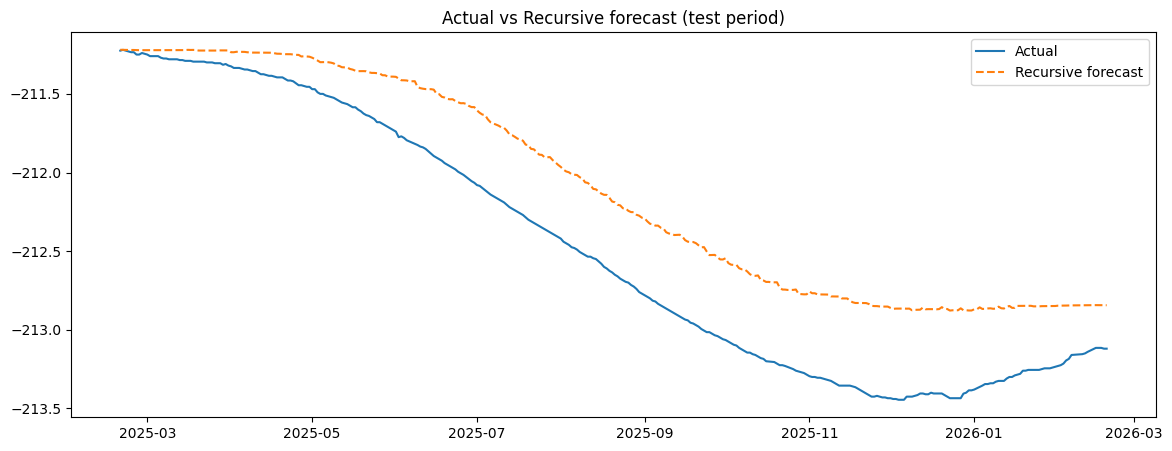

Lag_7             0.253364
Roll_Min_7d       0.214390
Roll_Max_7d       0.205748
Roll_Mean_7d      0.139780
Roll_Mean_30d     0.087722
Roll_Max_30d      0.071782
Lag_30            0.016093
Roll_Min_90d      0.003172
Roll_Mean_90d     0.002172
Roll_Max_90d      0.001210
Month_Sin         0.000834
Day_of_Year       0.000600
Roll_Std_90d      0.000533
Is_Rain_Season    0.000511
Year              0.000416
Month             0.000393
Roll_Min_30d      0.000378
Roll_Std_7d       0.000321
DayYear_Sin       0.000205
Roll_Std_30d      0.000197
dtype: float32


In [52]:
import xgboost as xgb
xgb_optuna_205_params = {'n_estimators': 1569, 'learning_rate': 0.015745965642344227, 'max_depth': 3, 'min_child_weight': 96, 'gamma': 0.00015861178371136264, 'subsample': 0.7080896247131288, 'colsample_bytree': 0.31198475309257795, 'reg_alpha': 1.5433593755038913e-08, 'reg_lambda': 2.49611000349147}
XGB_optuna = xgb.XGBRegressor(**xgb_optuna_205_params, objective='reg:squarederror', n_jobs=-1)
result = train_and_evaluate_recursive_with_test(test=test,train=train,model=XGB_optuna)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])

plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()

importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))

Evaluation on test period (recursive):
MAE: 0.7545 | RMSE: 0.8150 | MAPE: 0.0035
{'mae': 0.7545383972897247, 'rmse': 0.8149774671540642, 'mape': 0.003546028212359996}


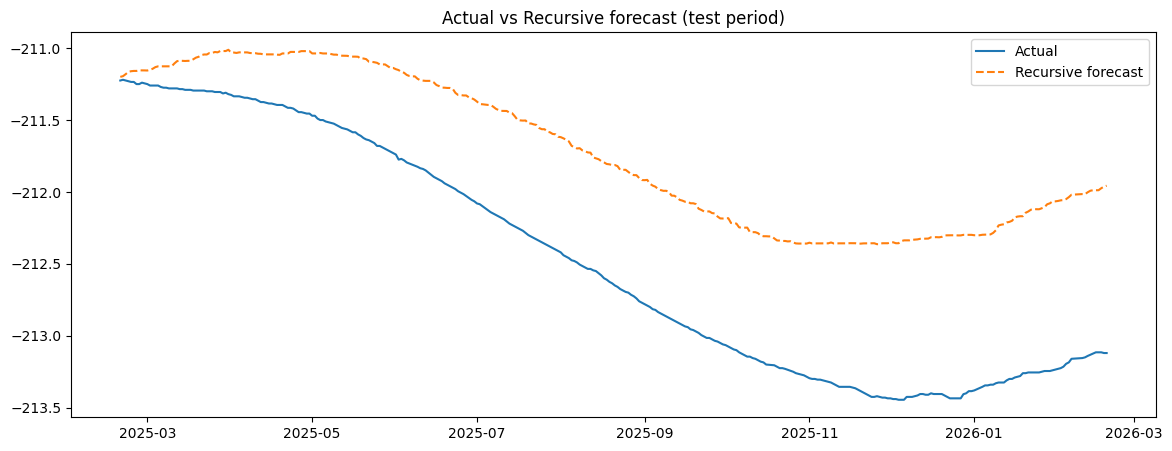

Roll_Max_7d      1017
Roll_Mean_7d      755
Roll_Std_7d       631
Roll_Min_7d       481
Roll_Std_30d      383
Day_of_Year       357
Lag_7             315
DayYear_Cos       286
Year              250
Lag_30            210
DayYear_Sin       208
Roll_Min_90d      200
Lag_365           191
Roll_Std_90d      190
Roll_Max_30d      166
Roll_Min_30d      141
Roll_Mean_90d     135
Roll_Max_90d      130
Month_Sin         128
Month             110
dtype: int32


In [53]:
params_optuna_lightgbm_380 ={'n_estimators': 2705, 'learning_rate': 0.032779968624430514, 'num_leaves': 98, 'max_depth': 5, 'min_child_samples': 33, 'min_split_gain': 0.0056320689837478545, 'subsample': 0.8820334531346841, 'subsample_freq': 5, 'colsample_bytree': 0.33386499066384884, 'reg_alpha': 1.4824897197228957e-06, 'reg_lambda': 0.0012449297738461869, 'min_child_weight': 11}
LightGBM_optuna = lgb.LGBMRegressor(**params_optuna_lightgbm_380, random_state=42, verbose=-1)
result = train_and_evaluate_recursive_with_test(test=test,train=train,model=LightGBM_optuna)
preds = result['preds']
y_test = result['y_test']
print(result['metrics'])

plt.figure(figsize=(14,5))
plt.plot(test.index[:len(preds)], test['Kinneret_Level'].iloc[:len(preds)], label='Actual')
plt.plot(preds.index, preds.values, label='Recursive forecast', linestyle='--')
plt.legend()
plt.title('Actual vs Recursive forecast (test period)')
plt.show()

importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))

In [54]:
importances = result['model'].feature_importances_
fi = pd.Series(importances, index=result['X_train'].columns).sort_values(ascending=False)
print(fi.head(20))

Roll_Max_7d      1017
Roll_Mean_7d      755
Roll_Std_7d       631
Roll_Min_7d       481
Roll_Std_30d      383
Day_of_Year       357
Lag_7             315
DayYear_Cos       286
Year              250
Lag_30            210
DayYear_Sin       208
Roll_Min_90d      200
Lag_365           191
Roll_Std_90d      190
Roll_Max_30d      166
Roll_Min_30d      141
Roll_Mean_90d     135
Roll_Max_90d      130
Month_Sin         128
Month             110
dtype: int32


In [55]:
import optuna.visualization as vis
display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

Getting ARIMA forecast...
Getting ETS forecast...
Training LightGBM (Recursive)...
Evaluation on test period (recursive):
MAE: 0.5571 | RMSE: 0.5927 | MAPE: 0.0026
Training XGBoost (Recursive)...
Evaluation on test period (recursive):
MAE: 0.3805 | RMSE: 0.4156 | MAPE: 0.0018


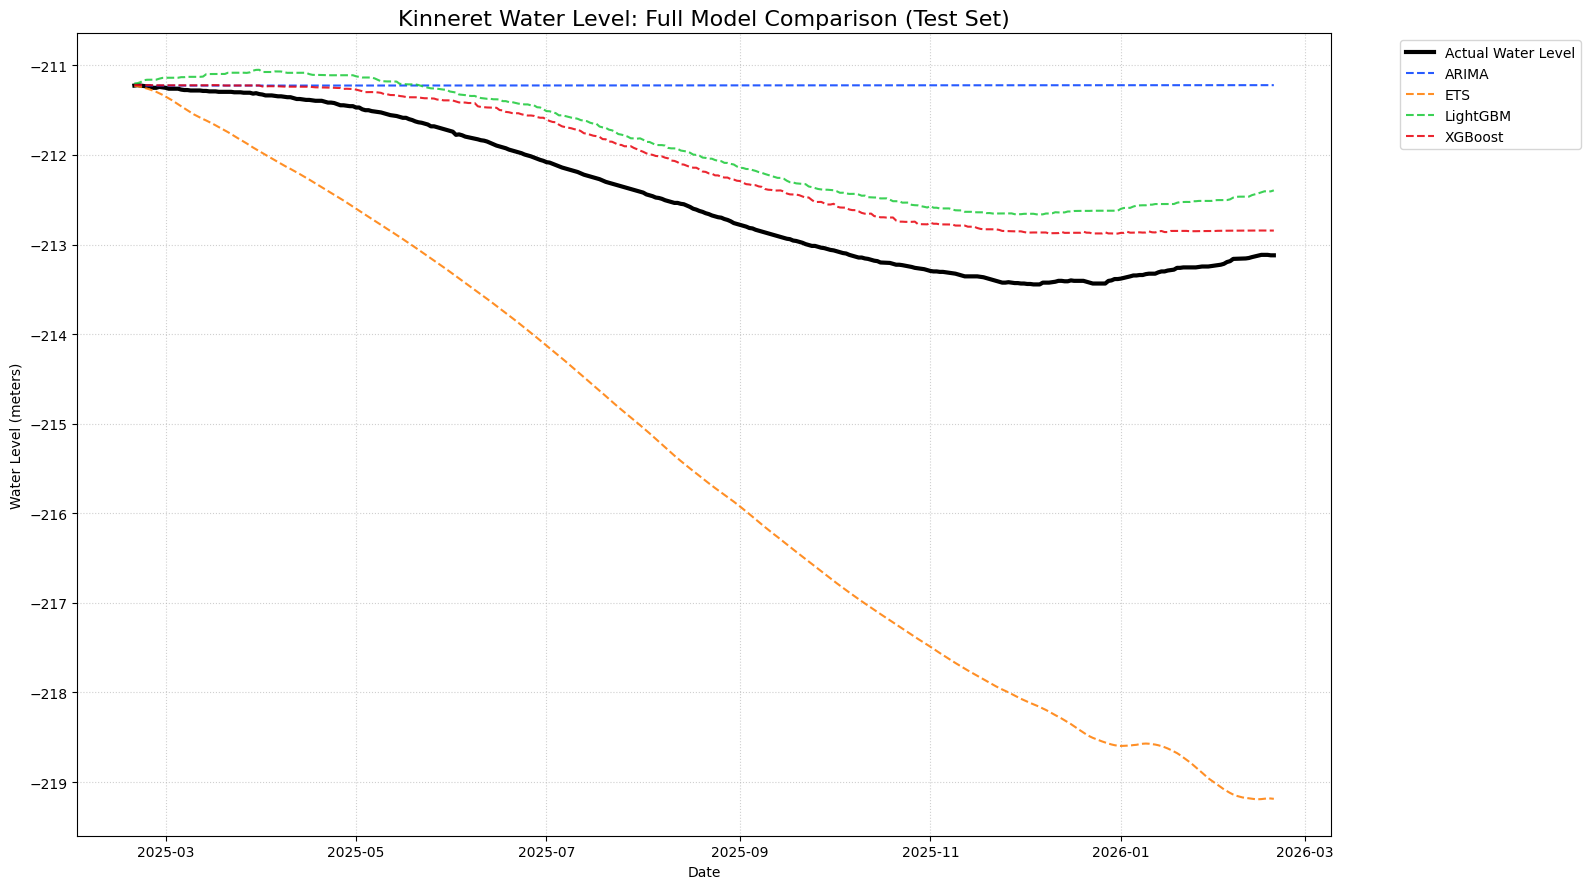

In [56]:
def train_evaluate_and_plot_all_models(
    train,
    test,
    arima_model_fit,
    ets_model_fit,
    lgb_params,
    xgb_params
):

    results = pd.DataFrame(index=test.index)
    results['Actual'] = test['Kinneret_Level']

    n_test = len(test)

    # =========================
    # 1️⃣ ARIMA
    # =========================
    print("Getting ARIMA forecast...")
    arima_forecast = arima_model_fit.get_forecast(steps=n_test).predicted_mean
    arima_forecast.index = test.index
    results['ARIMA'] = arima_forecast.values

    # =========================
    # 2️⃣ ETS
    # =========================
    print("Getting ETS forecast...")
    ets_forecast = ets_model_fit.forecast(steps=n_test)
    ets_forecast.index = test.index
    results['ETS'] = ets_forecast.values

    # =========================
    # 3️⃣ LightGBM (Recursive)
    # =========================
    print("Training LightGBM (Recursive)...")
    lgb_model = lgb.LGBMRegressor(**lgb_params, objective='regression', n_jobs=-1)
    lgb_res = train_and_evaluate_recursive_with_test(
        test=test,
        train=train,
        model=lgb_model
    )
    results['LightGBM'] = lgb_res['preds'].values

    # =========================
    # 4️⃣ XGBoost (Recursive)
    # =========================
    print("Training XGBoost (Recursive)...")
    xgb_model = xgb.XGBRegressor(**xgb_params, objective='reg:squarederror', n_jobs=-1)
    xgb_res = train_and_evaluate_recursive_with_test(
        test=test,
        train=train,
        model=xgb_model
    )
    results['XGBoost'] = xgb_res['preds'].values

    # =========================
    # 📊 Plot Everything
    # =========================
    plt.figure(figsize=(16, 9))

    # Actual
    sns.lineplot(
        x=results.index,
        y=results['Actual'],
        color='black',
        linewidth=3,
        label='Actual Water Level'
    )

    model_cols = [c for c in results.columns if c != 'Actual']
    palette = sns.color_palette("bright", len(model_cols))

    for i, col in enumerate(model_cols):
        sns.lineplot(
            x=results.index,
            y=results[col],
            label=col,
            color=palette[i],
            alpha=0.85,
            linestyle='--'
        )

    plt.title('Kinneret Water Level: Full Model Comparison (Test Set)', fontsize=16)
    plt.xlabel('Date')
    plt.ylabel('Water Level (meters)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results
final_preds = train_evaluate_and_plot_all_models(
    train=train,
    test=test,
    arima_model_fit=arima_model_fit,
    ets_model_fit=ets_model_fit,
    lgb_params=params_optuna_lightgbm_380,
    xgb_params=xgb_optuna_205_params
)


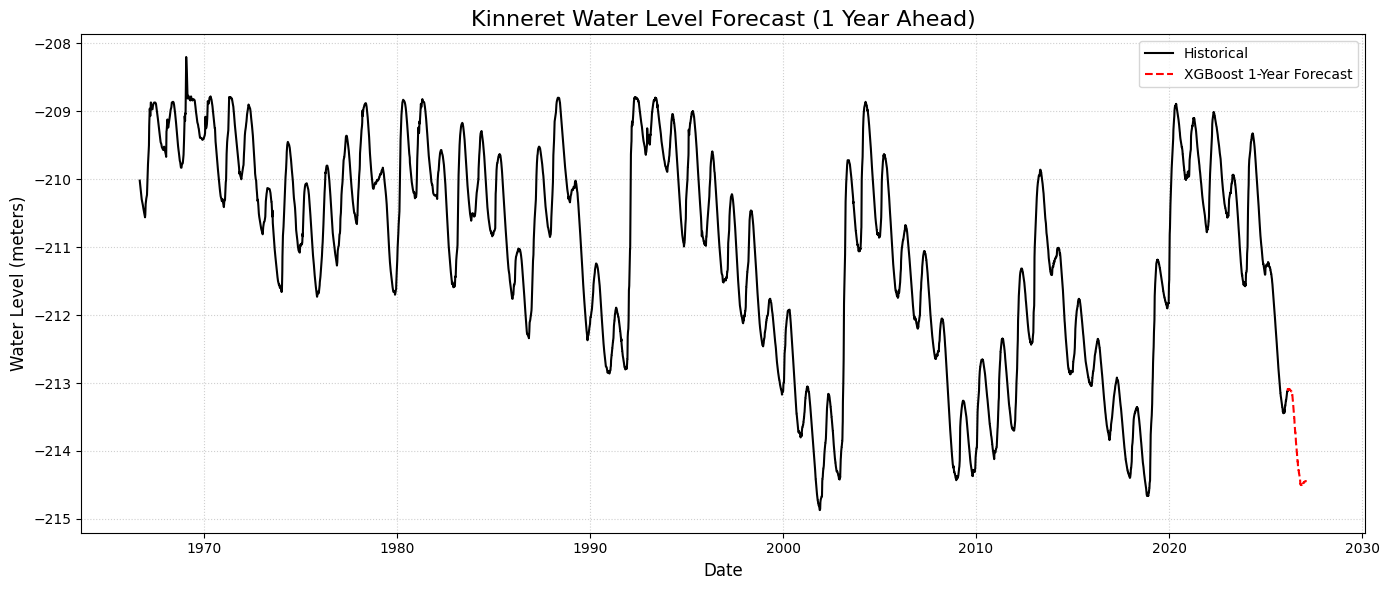

In [57]:
import joblib
from sklearn.base import clone
xgb_params = xgb_optuna_205_params
xgb_model = xgb.XGBRegressor(**xgb_params, objective='reg:squarederror', n_jobs=-1)
def future_1_year_forecast(df=df, target_col='Kinneret_Level', horizon=365, model=xgb_model):
    # Feature engineering
    df_feat = engineer_kinneret_features(df, lags=lags_Use, windows=windows_Use)
    X_df = df_feat.drop(columns=[target_col])
    y_df = df_feat[target_col]
    # Drop rows with incomplete features produced by shifting/rolling
    valid_idx = X_df.dropna().index.intersection(y_df.dropna().index)
    X_clean = X_df.loc[valid_idx].copy()
    y_clean = y_df.loc[valid_idx].copy()
    if len(X_clean) == 0:
        raise ValueError('No training rows after dropping NaNs. Check feature engineering lags/windows.')
    # Clone model so we don't overwrite the original passed object
    model_clone = clone(model)
    model_clone.fit(X_clean, y_clean)
    # Prepare true-history series for recursion (use original raw df target values)
    last_known_time = df.index.max()
    history_series = df[target_col].loc[:last_known_time].copy()
    # Recursive forecast using the trained clone
    preds = recursive_forecast(
        model=model_clone,
        history_series=history_series,
        periods=horizon,
        start_index=last_known_time,
        freq='1D'
    )
    import joblib

    joblib.dump(model_clone, 'xgboost_full_final.pkl')
    return preds
future = future_1_year_forecast()
plt.figure(figsize=(14,6))
plt.plot(df['Kinneret_Level'], label='Historical', color='black')
# ensure future is a Series with datetime index; reindex if necessary
if not isinstance(future, (pd.Series,)):
    future = pd.Series(future)
plt.plot(future, label='XGBoost 1-Year Forecast', linestyle='--', color='red')
plt.title('Kinneret Water Level Forecast (1 Year Ahead)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Water Level (meters)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



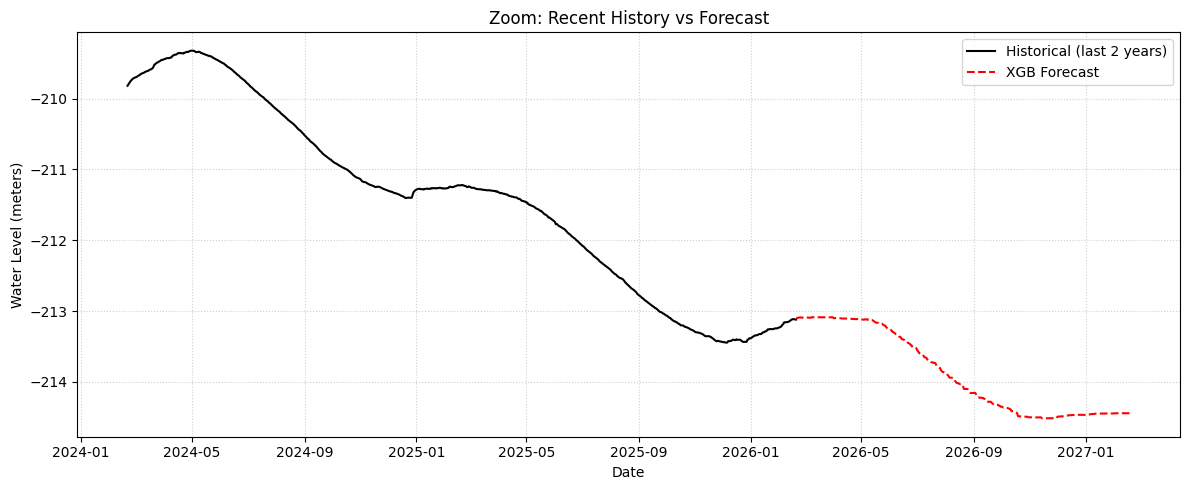

In [58]:
# Zoomed comparison: last 2 years of history vs first 90 days of forecast
import matplotlib.pyplot as plt

hist_zoom = df['Kinneret_Level'].last('730D')

plt.figure(figsize=(12,5))
plt.plot(hist_zoom.index, hist_zoom.values, label='Historical (last 2 years)', color='black')
plt.plot(future.index, future.values, label='XGB Forecast ', color='red', linestyle='--')
plt.title('Zoom: Recent History vs Forecast')
plt.xlabel('Date')
plt.ylabel('Water Level (meters)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
joblib.dump(xgb_model, 'xgboost_final.pkl')

['xgboost_final.pkl']